In [1]:
!pip install numpy pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import warnings

In [110]:
datadf=pd.read_csv('Restaurant_Reviews.tsv',sep='\t')
datadf.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [5]:
datadf.shape

(1000, 2)

In [6]:
datadf.isnull().sum()

Review    0
Liked     0
dtype: int64

In [7]:
datadf['Liked'].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

Step 2: Text cleaning & processessing


In [8]:
import re

In [9]:
import nltk

In [10]:
import string

In [ ]:
nltk.download('punkt_tab',download_dir='D:/Users/DELL/Documents/ML Projects/Sentiment_anaysis_project/venv/Lib/site-packages/nltk')
nltk.download('stopwords',download_dir='D:/Users/DELL/Documents/ML Projects/Sentiment_anaysis_project/venv/Lib/site-packages/nltk')

nltk.download('wordnet',download_dir='D:/Users/DELL/Documents/ML Projects/Sentiment_anaysis_project/venv/Lib/site-packages/nltk')

nltk.download('omw-1.4',download_dir='D:/Users/DELL/Documents/ML Projects/Sentiment_anaysis_project/venv/Lib/site-packages/nltk')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/soumya/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/soumya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/soumya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/soumya/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [111]:
stop_words= set(stopwords.words('english'))


In [112]:
lemmatizer = WordNetLemmatizer()

In [128]:
def preprocess(text):
    text= text.lower()
    text = re.sub(r"\b(not|no|never)\b\s+(\w+)", r"\1_\2", text)
    text= text.translate(str.maketrans('','',string.punctuation))
    #text = re.sub(r'\d+', '', text)
    tokens= word_tokenize(text)
    tokens= [w for w in tokens if w not in stop_words]
    tokens= [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

In [129]:
# apply the above function

datadf['Cleaned_review']= datadf['Review'].apply(preprocess)

In [130]:
# converting to Labels
datadf['Label']= datadf['Liked'].map({1:'Positive',0:'Negative'})

In [131]:
datadf.head()

,Review,Liked,Cleaned_review,Label
0,Wow... Loved this place.,1,wow loved place,Positive
1,Crust is not good.,0,crust notgood,Negative
2,Not tasty and the texture was just nasty.,0,nottasty texture nasty,Negative
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...,Positive
4,The selection on the menu was great and so wer...,1,selection menu great price,Positive


In [29]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 8.8 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 9.6 MB/s  0:00:036m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
from sklearn.model_selection import train_test_split

In [132]:
X=datadf["Cleaned_review"]
Y=datadf['Liked']

In [133]:
vectorizer = TfidfVectorizer()
X= vectorizer.fit_transform(datadf['Cleaned_review'])


In [134]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.20)

In [37]:
from sklearn.linear_model import LogisticRegression

In [135]:
lgr_model= LogisticRegression()
lgr_model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [136]:
# Evaluate
Y_pred=lgr_model.predict(X_test)
print('Accuracy:',accuracy_score(Y_test,Y_pred))



Accuracy: 0.79


In [137]:
cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[97 10]
 [32 61]]


<Figure size 400x200 with 0 Axes>

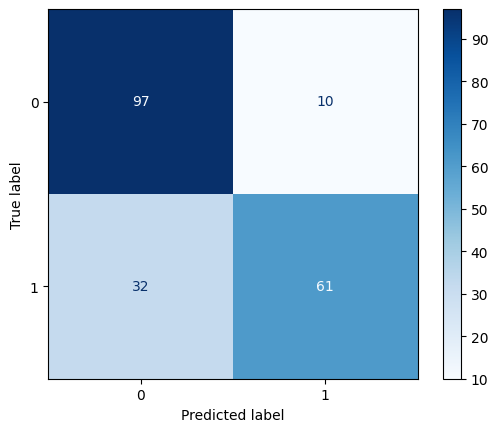

In [144]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(4,2))
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, cmap='Blues')
plt.show()


In [142]:
print("Classification Report:\n", classification_report(Y_test,Y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82       107
           1       0.86      0.66      0.74        93

    accuracy                           0.79       200
   macro avg       0.81      0.78      0.78       200
weighted avg       0.80      0.79      0.79       200



In [55]:
from sklearn.naive_bayes import MultinomialNB

In [138]:
NB_model = MultinomialNB()
NB_model.fit(X_train, Y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [139]:
Y_NBpred = NB_model.predict(X_test)


In [140]:
print('Accuracy:',accuracy_score(Y_test,Y_NBpred))


Accuracy: 0.77


In [141]:
print("Classification Report:\n",classification_report(Y_test,Y_NBpred))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.70      0.77       107
           1       0.71      0.85      0.77        93

    accuracy                           0.77       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.77      0.77       200



<Figure size 400x200 with 0 Axes>

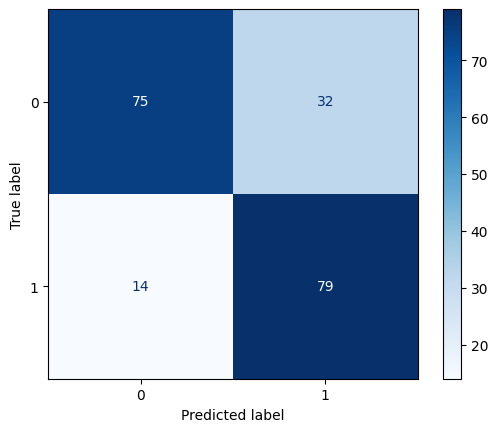

In [143]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(4,2))
ConfusionMatrixDisplay.from_predictions(Y_test, Y_NBpred, cmap='Blues')
plt.show()


  Goal is avoiding mislabeling reviews as positive (e.g., for automated responses), 
  Here Logistic Regression has higher recall and has slightly better overall performance.
  So go with Logistic Regression.

In [145]:
import pickle

In [147]:
pickle.dump(lgr_model, open("Sentiment_analysis.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model trained and saved!")

Model trained and saved!
